✅ Veri başarıyla yüklendi! Boyut: (20804, 40)

✅ İşlem Başarılı! Tüm özellikler 'featured_train_final.csv' dosyasına kaydedildi.
Toplam Özellik Sayısı: 5
Sütunlar: ['log_price', 'price', 'accommodates', 'neigh_value', 'min_nights_clean']


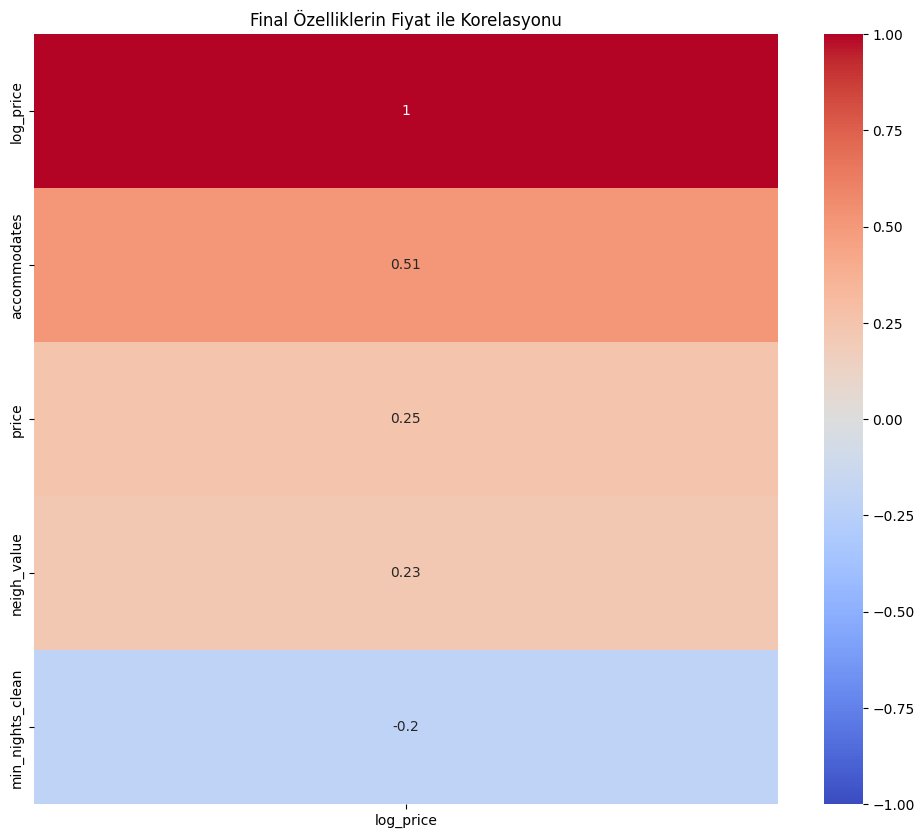

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
import os

# Uyarıları kapat
warnings.filterwarnings('ignore')

# ==========================================
# 1. VERİYİ YÜKLEME
# ==========================================
# Dosya yolunu ve adını birleştiriyoruz
folder_path = r'C:\Users\NURETTİN\OneDrive\Masaüstü\YZV311_2526_10\data\processed'
file_name = 'train_processed.csv'
full_path = os.path.join(folder_path, file_name)

try:
    df = pd.read_csv(full_path)
    print(f"✅ Veri başarıyla yüklendi! Boyut: {df.shape}")
except FileNotFoundError:
    print(f"❌ HATA: '{file_name}' dosyası bulunamadı.")
    print(f"Aranan yol: {full_path}")
    raise

# Referans Tarih
ref_date = datetime(2025, 6, 1)

# ==========================================
# 2. TEMEL ÖZELLİKLER (Kapasite, Konum vb.)
# ==========================================

# A. Kapasite (Banyo Sayısı)
if 'bathrooms_text' in df.columns:
    def extract_bath(x):
        try:
            x = str(x).lower()
            if 'half' in x: return 0.5
            return float(x.split()[0])
        except: return 1.0
    df['bathroom_count'] = df['bathrooms_text'].apply(extract_bath)
else:
    # Eğer bathrooms_text yoksa ve bathrooms varsa onu kullan, yoksa 1.0 ata
    df['bathroom_count'] = df.get('bathrooms', 1.0)

# B. Konum Değeri (Neigh Value)
if 'neighbourhood_cleansed' in df.columns:
    if df['price'].dtype == 'O':
        df['price'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
    neigh_price = df.groupby('neighbourhood_cleansed')['price'].median()
    df['neigh_value'] = df['neighbourhood_cleansed'].map(neigh_price).fillna(df['price'].median())
else:
    df['neigh_value'] = 0

# C. Lüks Skoru (DÜZELTİLEN KISIM)
luxury_keywords = ['bosphorus', 'sea', 'view', 'terrace', 'luxury', 'jacuzzi', 'residence', 'suite']

# Güvenli metin birleştirme
# Önce boş bir seri oluşturuyoruz
text_data = pd.Series("", index=df.index)

# Sütun varsa ekliyoruz, yoksa atlıyoruz
if 'name' in df.columns:
    text_data += df['name'].fillna('').astype(str) + ' '
if 'description' in df.columns:
    text_data += df['description'].fillna('').astype(str)

# Küçük harfe çevirip anahtar kelimeleri sayıyoruz
text_data = text_data.str.lower()
df['luxury_score'] = text_data.apply(lambda x: sum(1 for word in luxury_keywords if word in x))

# D. Amenities Count
if 'amenities' in df.columns:
    def count_amenities(text):
        try: return len(str(text).replace('[', '').replace(']', '').split(','))
        except: return 0
    df['amenities_count'] = df['amenities'].apply(count_amenities)
else:
    df['amenities_count'] = 0

# E. Diğer Temel Dönüşümler
if 'room_type' in df.columns:
    df['is_entire_home'] = (df['room_type'] == 'Entire home/apt').astype(int)
else: df['is_entire_home'] = 0

if 'latitude' in df.columns:
    center_lat, center_lon = 41.0370, 28.9851
    df['dist_to_center'] = np.sqrt((df['latitude'] - center_lat)**2 + (df['longitude'] - center_lon)**2)
else: df['dist_to_center'] = 0

if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_experience_days'] = (ref_date - df['host_since']).dt.days
    df['host_experience_days'] = df['host_experience_days'].fillna(df['host_experience_days'].median())
else: df['host_experience_days'] = 0

# Log Fiyat
df['log_price'] = np.log1p(df['price'])

# ==========================================
# 3. YENİ BAĞIMSIZ ÖZELLİKLER (Profesyonellik, Klima vb.)
# ==========================================

# 1. Ev Sahibi Profesyonelliği
if 'calculated_host_listings_count' in df.columns:
    df['host_listings_log'] = np.log1p(df['calculated_host_listings_count'].fillna(1))
else:
    df['host_listings_log'] = 0

# 2. Minimum Konaklama
if 'minimum_nights' in df.columns:
    df['min_nights_clean'] = df['minimum_nights'].clip(upper=30)
else:
    df['min_nights_clean'] = 1

# 3. Spesifik Olanaklar (Klima & Güvenlik)
if 'amenities' in df.columns:
    amenities_str = df['amenities'].astype(str).str.lower()
    df['has_ac'] = amenities_str.apply(lambda x: 1 if 'air conditioning' in x or 'klima' in x else 0)
    df['has_security'] = amenities_str.apply(lambda x: 1 if 'security' in x or 'doorman' in x else 0)
else:
    df['has_ac'] = 0
    df['has_security'] = 0

# 4. Anında Rezervasyon
if 'instant_bookable' in df.columns:
    df['instant_bookable_binary'] = df['instant_bookable'].map({'t': 1, 'f': 0}).fillna(0)
else:
    df['instant_bookable_binary'] = 0

final_features = [
    'log_price', 'price',           # Hedef
    'accommodates',                 # Kapasite
    'neigh_value',                  # Konum

    'min_nights_clean',             # Kiralama Tipi
]

# Sadece mevcut olanları seç
cols_to_save = [c for c in final_features if c in df.columns]
df_final = df[cols_to_save].copy()

# Kaydet
output_filename = 'featured_train_final.csv'
df_final.to_csv(output_filename, index=False)

print(f"\n✅ İşlem Başarılı! Tüm özellikler '{output_filename}' dosyasına kaydedildi.")
print(f"Toplam Özellik Sayısı: {df_final.shape[1]}")
print("Sütunlar:", df_final.columns.tolist())

# Korelasyon Haritası
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(df_final.corr()[['log_price']].sort_values(by='log_price', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Final Özelliklerin Fiyat ile Korelasyonu')
plt.show()

In [5]:
# 1. Sadece sayısal sütunları seçelim
numeric_data = train.select_dtypes(include=[np.number])

# 2. Korelasyon matrisini hesaplayalım
corr_matrix = numeric_data.corr()

# 3. Yüksek korelasyonlu çiftleri bulmak için bir fonksiyon
def get_high_correlations(corr_matrix, threshold=0.7):
    # Korelasyon matrisinin üst üçgenini al (çiftleri iki kez görmemek için)
    # ve 1.0 olan diyagonal (kendisiyle olan) değerleri hariç tut
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Eşik değerden yüksek olanları bul
    # Mutlak değer (abs) kullanıyoruz çünkü negatif güçlü ilişki de önemlidir (-0.9 gibi)
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column].abs() > threshold)]
    
    # Çiftleri ve değerlerini yazdıralım
    print(f"Korelasyonu {threshold}'dan yüksek olan çiftler:\n")
    found = False
    
    # Matrisi düzleştirip sıralayalım
    stacked_corr = upper_tri.stack().sort_values(ascending=False)
    
    for (col1, col2), val in stacked_corr.items():
        if abs(val) > threshold:
            print(f"{col1} - {col2}: {val:.4f}")
            found = True
            
    if not found:
        print("Belirtilen eşik değerin üzerinde korelasyon bulunamadı.")

# 4. Fonksiyonu çalıştır (Eşik değerini 0.70 olarak belirledik, değiştirebilirsiniz)
get_high_correlations(corr_matrix, threshold=0.70)

# 5. Görselleştirme (Isı Haritası - Heatmap)
plt.figure(figsize=(20, 15))
# Üst üçgeni maskeleyerek daha temiz bir görüntü elde edelim
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Özellikler Arası Korelasyon Matrisi')
plt.show()

NameError: name 'train' is not defined